In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



In [4]:
df = pd.read_csv('../Data/CC GENERAL.csv')
df.drop('CUST_ID', axis=1, inplace=True)

filtro_cero_pagos = (df['MINIMUM_PAYMENTS'].isnull()) & (df['PAYMENTS'] == 0.0)
df.loc[filtro_cero_pagos, 'MINIMUM_PAYMENTS'] = 0.0
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

pca = PCA(n_components=10, random_state=42)
df_pca = pca.fit_transform(df_scaled)



C:\Users\USER\AppData\Local\Temp\ipykernel_47888\1251824540.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_47888\1251824540.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

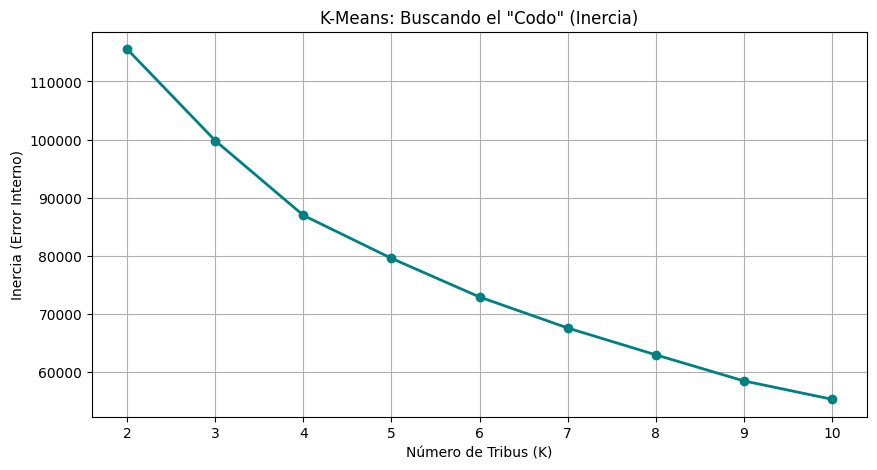


--- AUDITORÍA MATEMÁTICA DE K-MEANS ---
 K_Tribus       Inercia  Silhouette_Score
        3  99800.145295          0.258660
        9  58506.333033          0.248922
        8  62992.402824          0.244572
        7  67607.058014          0.238590
       10  55351.556042          0.238416
        2 115530.870329          0.224217
        6  72933.615263          0.224090
        4  86965.751877          0.217763
        5  79577.995611          0.211803


In [5]:
rango_k = range(2, 11) 
inercia = []
silhouette_scores = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(df_pca)
    inercia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca, etiquetas))


plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercia, marker='o', color='teal', linewidth=2)
plt.title('K-Means: Buscando el "Codo" (Inercia)')
plt.xlabel('Número de Tribus (K)')
plt.ylabel('Inercia (Error Interno)')
plt.xticks(rango_k)
plt.grid(True)
plt.show()

df_kmeans_eval = pd.DataFrame({
    'K_Tribus': rango_k, 
    'Inercia': inercia, 
    'Silhouette_Score': silhouette_scores
})
print("\n--- AUDITORÍA MATEMÁTICA DE K-MEANS ---")
print(df_kmeans_eval.sort_values(by='Silhouette_Score', ascending=False).to_string(index=False))

In [7]:
from sklearn.cluster import KMeans
import seaborn as sns

--- POBLACIÓN POR TRIBU ---
Tribu_Marketing
0    6108
1    1600
2    1242
Name: count, dtype: int64


--- ADN FINANCIERO DE LAS TRIBUS (Promedios en USD) ---
                 BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS
Tribu_Marketing                                                          
0                 798.68     503.30        328.58       3265.99    906.92
1                3975.80     379.31       3864.63       6664.69   3015.60
2                2224.16    4265.43        459.35       7738.85   4144.31


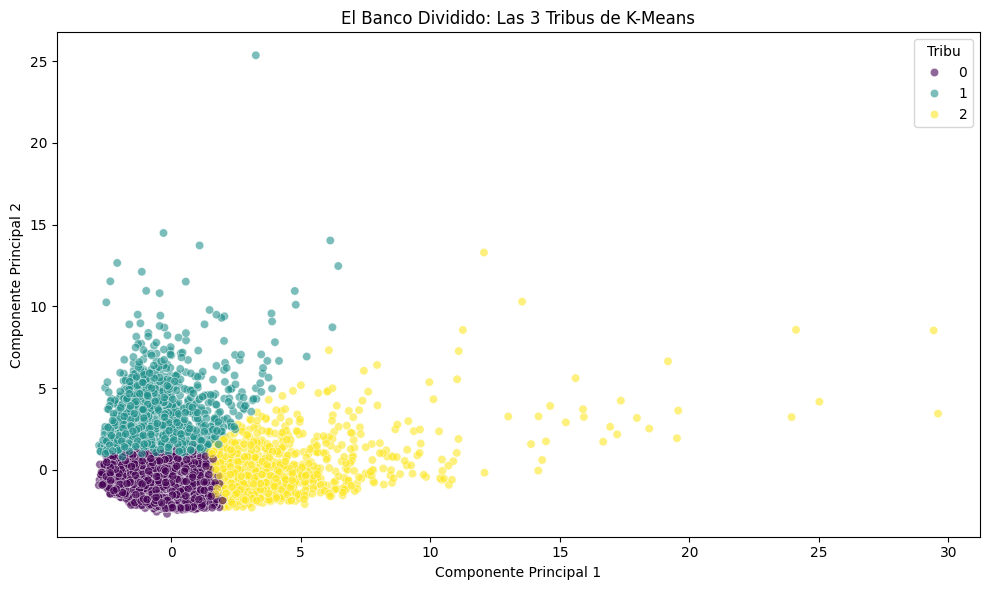

In [8]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Tribu_Marketing'] = kmeans_final.fit_predict(df_pca)

print("--- POBLACIÓN POR TRIBU ---")
print(df['Tribu_Marketing'].value_counts())
print("\n")

columnas_clave = [
    'BALANCE',           # Deuda actual
    'PURCHASES',         # Total de compras
    'CASH_ADVANCE',      # Efectivo retirado 
    'CREDIT_LIMIT',      # Límite de la tarjeta
    'PAYMENTS'           # Cuánto pagan al mes
]

perfil_tribus = df.groupby('Tribu_Marketing')[columnas_clave].mean().round(2)
print("--- ADN FINANCIERO DE LAS TRIBUS (Promedios en USD) ---")
print(perfil_tribus)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca[:, 0], 
    y=df_pca[:, 1], 
    hue=df['Tribu_Marketing'], 
    palette='viridis', 
    alpha=0.6
)
plt.title('El Banco Dividido: Las 3 Tribus de K-Means')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Tribu')
plt.tight_layout()
plt.show()

--- NUEVA POBLACIÓN (SIN OUTLIERS EXTREMOS) ---
Tribu_Topada
2    5264
1    1940
0    1746
Name: count, dtype: int64

--- NUEVO ADN FINANCIERO (Promedios Topados) ---
              BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS
Tribu_Topada                                                          
0             1840.32    2667.21        435.70       6509.50   2859.80
1             3224.86     284.44       2707.31       5847.41   2161.63
2              670.05     411.25        247.09       3090.68    765.02


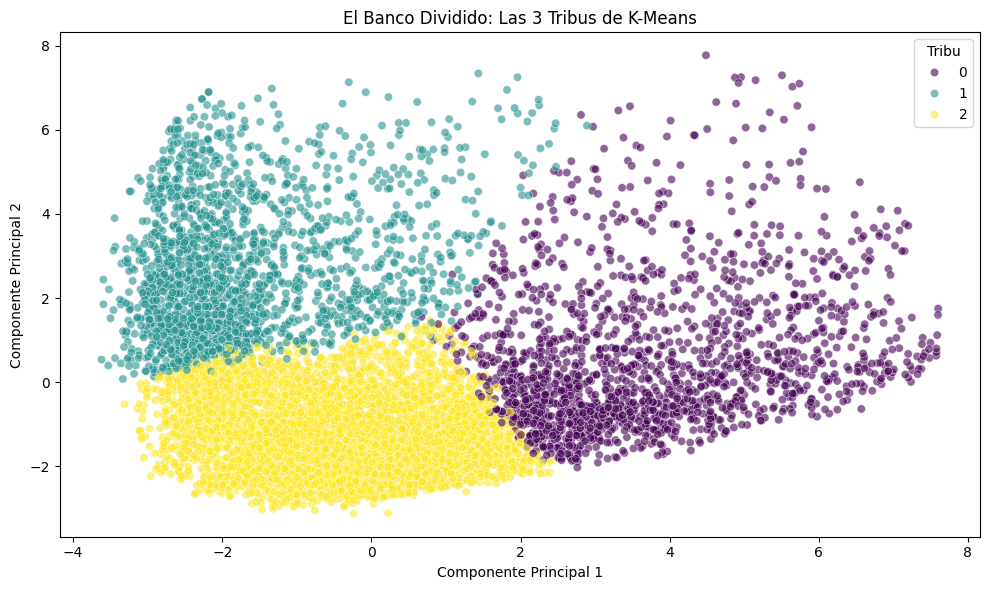

In [10]:
df_topado = df.copy()

columnas_fin = df_topado.columns.drop(['Tribu_Marketing', 'Cluster_DBSCAN'], errors='ignore')

for col in columnas_fin:
    limite_superior = df_topado[col].quantile(0.95)
    df_topado[col] = np.where(df_topado[col] > limite_superior, limite_superior, df_topado[col])

scaler_top = StandardScaler()
df_scaled_top = scaler_top.fit_transform(df_topado[columnas_fin])

pca_top = PCA(n_components=10, random_state=42)
df_pca_top = pca_top.fit_transform(df_scaled_top)

kmeans_top = KMeans(n_clusters=3, random_state=42, n_init=10)
df_topado['Tribu_Topada'] = kmeans_top.fit_predict(df_pca_top)

columnas_clave = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
perfil_topado = df_topado.groupby('Tribu_Topada')[columnas_clave].mean().round(2)

print("--- NUEVA POBLACIÓN (SIN OUTLIERS EXTREMOS) ---")
print(df_topado['Tribu_Topada'].value_counts())
print("\n--- NUEVO ADN FINANCIERO (Promedios Topados) ---")
print(perfil_topado)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca_top[:, 0], 
    y=df_pca_top[:, 1], 
    hue=df_topado['Tribu_Topada'], 
    palette='viridis', 
    alpha=0.6
)
plt.title('El Banco Dividido: Las 3 Tribus de K-Means')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Tribu')
plt.tight_layout()
plt.show()

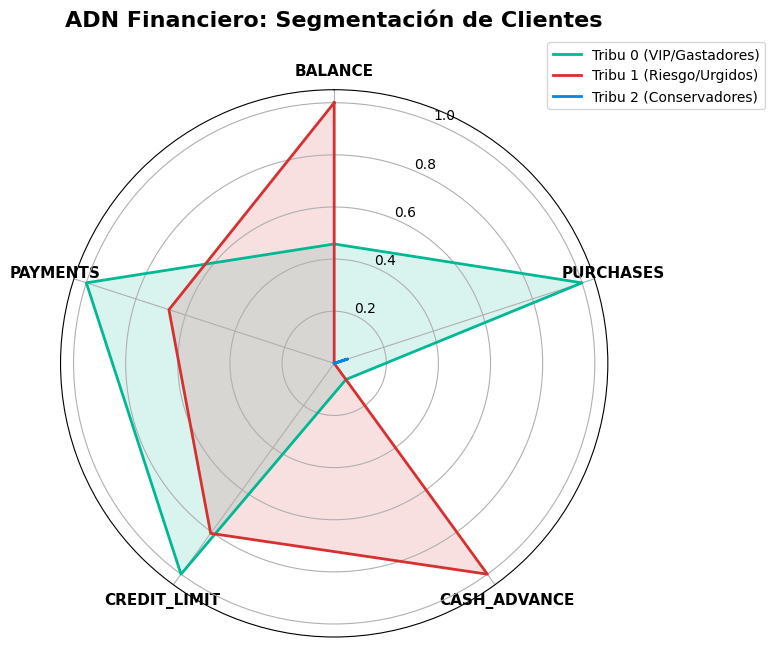

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler_radar = MinMaxScaler()
perfil_normalizado = pd.DataFrame(
    scaler_radar.fit_transform(perfil_topado), 
    columns=perfil_topado.columns, 
    index=perfil_topado.index
)

categorias = list(perfil_normalizado.columns)
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, size=11, weight='bold')

colores = ['#00b894', '#d63031', '#0984e3']
nombres_tribus = ['Tribu 0 (VIP/Gastadores)', 'Tribu 1 (Riesgo/Urgidos)', 'Tribu 2 (Conservadores)']

for idx, color, nombre in zip(perfil_normalizado.index, colores, nombres_tribus):
    valores = perfil_normalizado.loc[idx].values.flatten().tolist()
    valores += valores[:1] 
    
    ax.plot(angulos, valores, color=color, linewidth=2, linestyle='solid', label=nombre)
    ax.fill(angulos, valores, color=color, alpha=0.15)

plt.title('ADN Financiero: Segmentación de Clientes', size=16, weight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()